In [1]:
import sys
import os
from dotenv import load_dotenv
import time
import re
import json
import random
import string
import unicodedata

import pandas as pd
import numpy as np

from pathlib import Path
from transformers import pipeline, AutoTokenizer
from datasets import load_dataset
import torch
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from google import genai
from google.genai import types
from google.api_core.exceptions import ResourceExhausted

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing the 'src' directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_prepared_splits

In [2]:
RANDOM_SEED = 42
N_SAMPLE = 100

DATASET_NAME = "timonziegenbein/appropriateness-corpus"
MODEL_NAME = "timonziegenbein/appropriateness-classifier-binary"

TEXT_COL = "post_text"
TEXT_NORM_COL = "text_norm"
LABEL_COL = "Inappropriateness"
ID_COL = "post_id"
APPROPRIATE_LABEL = "LABEL_0"
INAPPROPRIATE_LABEL = "LABEL_1"

MAX_LENGTH = 512
BATCH_SIZE = 16
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(DEVICE)


# Google API Setup
load_dotenv(".env")
client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

LLM_NAME = "gemini-3-flash-preview"
LLM_BATCH_SIZE = 5
SECONDS_BETWEEN_SUCCESSFUL_BATCHES = 30
MAX_RETRIES_PER_BATCH = 20
MAX_RETRIES = 5


BASE_DIR = PROJECT_ROOT / "results"
OUTPUT_DIR = BASE_DIR / "llm_reference"
BASE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_PATH = OUTPUT_DIR / "llm_test_tp_spans.csv"

mps


In [ ]:
pipe = pipeline(
    "text-classification",
    model=MODEL_NAME,
    device=DEVICE,
    top_k=None,
    truncation=True,
    max_length=MAX_LENGTH
)

tokenizer = pipe.tokenizer
MASK_TOKEN = tokenizer.mask_token if tokenizer.mask_token is not None else "[MASK]"

# Load prepared data

In [4]:
df_all, train_df, val_df, test_df = load_prepared_splits()

print("All:", df_all.shape)
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)


print("Train confusion types:")
display(train_df["confusion_type"].value_counts())

print("Validation confusion types:")
display(val_df["confusion_type"].value_counts())

print("Test confusion types:")
display(test_df["confusion_type"].value_counts())

All: (2191, 30)
Train: (1533, 30)
Validation: (220, 30)
Test: (438, 30)
Train confusion types:


confusion_type
TP    785
TN    652
FN     48
FP     48
Name: count, dtype: int64

Validation confusion types:


confusion_type
TP    88
TN    66
FN    36
FP    30
Name: count, dtype: int64

Test confusion types:


confusion_type
TP    186
TN    142
FP     71
FN     39
Name: count, dtype: int64

In [52]:
df = test_df[test_df["confusion_type"] == "TP"]
print(df.shape)
df.head()

(186, 30)


,post_id,source_dataset,issue,post_text,Inappropriateness,Toxic Emotions,Excessive Intensity,Emotional Deception,Missing Commitment,Missing Seriousness,...,global_row_id,text_norm,p_inappropriate_original,predicted_label,predicted_score,confusion_type,is_true_positive,is_false_negative,is_false_positive,is_true_negative
1,8,0,Tv is better than books:,I thick that book are better than TV is it is ...,1,0,0,0,0,0,...,1754,I thick that book are better than TV is it is ...,0.997475,LABEL_1,0.997475,TP,True,False,False,False
2,9,0,Tv is better than books:,Books enlighten the soul. Books don't destroy ...,1,1,1,1,1,0,...,1755,Books enlighten the soul. Books don't destroy ...,0.998255,LABEL_1,0.998255,TP,True,False,False,False
3,12,0,India has the potential to lead the world:,india is is good adopter but a bad developer a...,1,0,0,0,1,0,...,1756,india is is good adopter but a bad developer a...,0.995627,LABEL_1,0.995627,TP,True,False,False,False
5,18,0,William farquhar ought to be honoured as the r...,Raffles had written his discovery wrongly as 2...,1,0,0,0,0,0,...,1758,Raffles had written his discovery wrongly as 2...,0.962887,LABEL_1,0.962887,TP,True,False,False,False
6,22,0,Evolution vs creation:,"I am a nurse and the more I studied biology, t...",1,0,0,0,0,0,...,1759,"I am a nurse and the more I studied biology, t...",0.992264,LABEL_1,0.992264,TP,True,False,False,False


In [53]:
required_cols = [
    "global_row_id",
    "Inappropriateness",
    "p_inappropriate_original",
    TEXT_NORM_COL
]

for c in required_cols:
    if c not in df.columns:
        raise ValueError(f"Missing required column: {c}")

sample_n = (
    df.sample(n=min(N_SAMPLE, len(df)), random_state=RANDOM_SEED)
      .reset_index(drop=True)
)

sample_path = Path("results/llm_reference")
sample_path.mkdir(parents=True, exist_ok=True)

sample_n.to_csv(sample_path / "sample_n_true_positives.csv", index=False)

sample_n[["global_row_id", "post_id", "split", "issue", TEXT_NORM_COL, "p_inappropriate_original"]].head()

,global_row_id,post_id,split,issue,text_norm,p_inappropriate_original
0,2007,1241,test,Jack thompson stance: do you think that jack...,Violence is perpetuated and caused by society....,0.997943
1,2150,1977,test,Will cigarettes finally become illegal?:,"in response to another person's answer, if cig...",0.998251
2,2162,2023,test,Is it moral for a nation to assasinate a forei...,"This is way too much of a blanket assertion, j...",0.998020
3,1985,1117,test,Is porn wrong:,jarman: porn is wrong because it sholud be in ...,0.998431
4,1984,1114,test,Is porn wrong:,"This not only degrades morality, it also affec...",0.998185


# LLM Setup

In [60]:
BATCH_SCHEMA = {
    "type": "object",
    "properties": {
        "annotations": {
            "type": "array",
            "items": {
                "type": "object",
                "properties": {
                    "argument_id": {
                        "type": "string"
                    },
                    "spans": {
                        "type": "array",
                        "items": {
                            "type": "object",
                            "properties": {
                                "span_text": {
                                    "type": "string"
                                },
                                "char_start": {
                                    "type": "integer"
                                },
                                "char_end": {
                                    "type": "integer"
                                },
                                "confidence": {
                                    "type": "number"
                                }
                            },
                            "required": [
                                "span_text",
                                "char_start",
                                "char_end",
                                "confidence"
                            ]
                        }
                    }
                },
                "required": [
                    "argument_id",
                    "spans"
                ]
            }
        }
    },
    "required": [
        "annotations"
    ]
}

In [61]:
SYSTEM_PROMPT_BATCH = """
You are annotating argumentative texts for inappropriateness.

Each input argument is already labeled as inappropriate.
For each argument, identify one or more minimal text spans that best explain why the argument may be considered inappropriate.

A relevant span may indicate, for example:
- toxic or insulting language,
- excessive emotional intensity,
- missing seriousness,
- missing openness to discussion,
- unclear meaning,
- missing relevance to the issue,
- or another flaw that makes the argumentative language inappropriate.

Annotation rules:
1. Return one or more spans per argument.
2. Each span must occur verbatim in the original argument text.
3. Do not paraphrase.
4. Prefer minimal spans over whole sentences.
5. Do not select neutral context unless it is necessary.
6. Character offsets must refer to the original argument text.
7. Output valid JSON only.
8. Return one annotation object for every input argument_id.
9. Keep spans as minimal as possible.
10. If several separate parts independently contribute to inappropriateness, return them as separate spans.
"""

In [ ]:
def extract_retry_delay_seconds(error_message, default=120):
    """
    Extract retry delay from Gemini error messages.
    Falls back to default seconds.
    """
    text = str(error_message)

    match = re.search(r"retryDelay['\"]?: ['\"]?(\d+)s", text)
    if match:
        return int(match.group(1)) + 10

    match = re.search(r"retry in ([0-9.]+)s", text)
    if match:
        return int(float(match.group(1))) + 10

    return default


def parse_bool(value):
    """
    Robustly parse booleans from bools, strings, numbers, or missing values.
    """
    if pd.isna(value):
        return False

    if isinstance(value, bool):
        return value

    return str(value).strip().lower() in ["true", "1", "yes"]


def dumps_json(value):
    """
    Serialize Python objects as JSON strings for CSV storage.
    """
    return json.dumps(value, ensure_ascii=False)


def loads_json_list(value):
    """
    Parse a JSON list from a CSV cell.
    Returns an empty list for missing or invalid values.
    """
    if pd.isna(value):
        return []

    if isinstance(value, list):
        return value

    try:
        parsed = json.loads(value)
        return parsed if isinstance(parsed, list) else []
    except Exception:
        return []


def normalize_annotation_spans(annotation):
    """
    Normalize an annotation object to a list of span dictionaries.

    Preferred new format:
    {
        "argument_id": "...",
        "spans": [
            {
                "span_text": "...",
                "char_start": 0,
                "char_end": 10,
                "confidence": 0.8
            }
        ]
    }

    The function also supports the old single-span format for robustness:
    {
        "argument_id": "...",
        "span_text": "...",
        "char_start": 0,
        "char_end": 10,
        "confidence": 0.8
    }
    """
    if annotation is None:
        return []

    if "spans" in annotation and isinstance(annotation["spans"], list):
        return annotation["spans"]

    if all(key in annotation for key in ["span_text", "char_start", "char_end"]):
        return [{
            "span_text": annotation.get("span_text"),
            "char_start": annotation.get("char_start"),
            "char_end": annotation.get("char_end"),
            "confidence": annotation.get("confidence")
        }]

    return []


def validate_and_fix_span(argument_text, span_text, char_start, char_end):
    """
    Validate and, if needed, fix character offsets for one span.

    A span is valid if the final span text occurs verbatim in the argument.
    If the provided offsets do not match, the function tries to recover offsets
    by searching for the span text in the original argument.
    """
    argument_text = str(argument_text)
    span_text = "" if span_text is None else str(span_text)

    result = {
        "valid": False,
        "fixed": False,
        "span_text": span_text,
        "char_start": None,
        "char_end": None,
        "error": None
    }

    if not span_text.strip():
        result["error"] = "empty_span"
        return result

    try:
        char_start_int = int(char_start)
        char_end_int = int(char_end)
    except Exception:
        char_start_int = None
        char_end_int = None

    # Case 1: Provided offsets are correct.
    if (
        char_start_int is not None
        and char_end_int is not None
        and 0 <= char_start_int < char_end_int <= len(argument_text)
        and argument_text[char_start_int:char_end_int] == span_text
    ):
        result.update({
            "valid": True,
            "fixed": False,
            "char_start": char_start_int,
            "char_end": char_end_int
        })
        return result

    # Case 2: Recover offsets from exact span text.
    first_idx = argument_text.find(span_text)

    if first_idx != -1:
        result.update({
            "valid": True,
            "fixed": True,
            "char_start": first_idx,
            "char_end": first_idx + len(span_text)
        })
        return result

    # Case 3: Recover offsets from stripped span text.
    stripped = span_text.strip()
    first_idx = argument_text.find(stripped)

    if first_idx != -1:
        result.update({
            "valid": True,
            "fixed": True,
            "span_text": stripped,
            "char_start": first_idx,
            "char_end": first_idx + len(stripped)
        })
        return result

    result["error"] = "span_not_found"
    return result


def validate_and_fix_spans(argument_text, spans):
    """
    Validate and fix all spans for one argument.

    The returned values are always lists. Invalid spans are excluded from the
    final valid span lists, but their errors are retained for debugging.
    """
    span_texts = []
    char_starts_original = []
    char_ends_original = []
    char_starts = []
    char_ends = []
    confidences = []

    fixed_flags = []
    errors = []
    raw_spans = []

    spans = [] if spans is None else spans

    for span in spans:
        if not isinstance(span, dict):
            errors.append("invalid_span_object")
            continue

        raw_spans.append(span)

        span_text = span.get("span_text")
        char_start_original = span.get("char_start")
        char_end_original = span.get("char_end")
        confidence = span.get("confidence")

        validation = validate_and_fix_span(
            argument_text=argument_text,
            span_text=span_text,
            char_start=char_start_original,
            char_end=char_end_original
        )

        errors.append(validation["error"])
        fixed_flags.append(validation["fixed"])

        if validation["valid"]:
            span_texts.append(validation["span_text"])
            char_starts_original.append(char_start_original)
            char_ends_original.append(char_end_original)
            char_starts.append(validation["char_start"])
            char_ends.append(validation["char_end"])
            confidences.append(confidence)

    return {
        "llm_span_texts": span_texts,
        "llm_char_starts_original": char_starts_original,
        "llm_char_ends_original": char_ends_original,
        "llm_char_starts": char_starts,
        "llm_char_ends": char_ends,
        "llm_confidences": confidences,
        "llm_raw_spans": raw_spans,
        "llm_fixed_offsets": fixed_flags,
        "llm_errors": errors,
        "llm_valid": len(span_texts) > 0,
        "n_llm_spans": len(span_texts)
    }


def build_batch_payload(batch_df, text_col):
    """
    Build the JSON payload sent to Gemini for a batch of arguments.
    """
    arguments = []

    for _, row in batch_df.iterrows():
        arguments.append({
            "argument_id": str(row["global_row_id"]),
            "issue": str(row.get("issue", "")),
            "argument": str(row[text_col])
        })

    return {
        "arguments": arguments
    }


def annotate_batch_gemini_with_retry(batch_df, text_col):
    """
    Annotate a batch of arguments with Gemini and retry on quota or temporary errors.
    """
    payload = build_batch_payload(batch_df, text_col)

    prompt = (
        SYSTEM_PROMPT_BATCH
        + "\n\nInput:\n"
        + json.dumps(payload, ensure_ascii=False)
    )

    last_error = None

    for attempt in range(1, MAX_RETRIES_PER_BATCH + 1):
        try:
            response = client.models.generate_content(
                model=LLM_NAME,
                contents=prompt,
                config=types.GenerateContentConfig(
                    temperature=0,
                    response_mime_type="application/json",
                    response_schema=BATCH_SCHEMA
                )
            )

            parsed = json.loads(response.text)

            if "annotations" not in parsed:
                raise ValueError(f"No 'annotations' key in response: {parsed}")

            annotations = parsed["annotations"]

            expected_ids = set(batch_df["global_row_id"].astype(str))
            returned_ids = set(str(a.get("argument_id")) for a in annotations)

            missing_ids = expected_ids - returned_ids

            if missing_ids:
                raise ValueError(f"Missing annotations for ids: {missing_ids}")

            return annotations

        except ResourceExhausted as e:
            last_error = e
            retry_delay = extract_retry_delay_seconds(e, default=180)
            wait_seconds = max(retry_delay, min(900, 60 * attempt))

            print(
                f"429 RESOURCE_EXHAUSTED for batch "
                f"{batch_df['global_row_id'].tolist()} "
                f"(attempt {attempt}/{MAX_RETRIES_PER_BATCH}). "
                f"Waiting {wait_seconds}s..."
            )

            time.sleep(wait_seconds)

        except Exception as e:
            last_error = e
            wait_seconds = min(300, 20 * attempt)

            print(
                f"Error for batch {batch_df['global_row_id'].tolist()} "
                f"(attempt {attempt}/{MAX_RETRIES_PER_BATCH}): {e}. "
                f"Waiting {wait_seconds}s..."
            )

            time.sleep(wait_seconds)

    raise RuntimeError(
        f"Batch failed after {MAX_RETRIES_PER_BATCH} retries. Last error: {last_error}"
    )


def process_batch_annotations(batch_df, annotations, text_col):
    """
    Convert Gemini batch annotations into one CSV row per argument.

    The span-related fields are always stored as JSON lists:
    - llm_span_texts
    - llm_char_starts_original
    - llm_char_ends_original
    - llm_char_starts
    - llm_char_ends
    - llm_confidences

    Even if Gemini returns only one span, the CSV cell contains a list.
    """
    ann_by_id = {
        str(a["argument_id"]): a
        for a in annotations
    }

    rows = []

    for _, row in batch_df.iterrows():
        argument_id = str(row["global_row_id"])
        argument_text = str(row[text_col])

        ann = ann_by_id.get(argument_id)

        if ann is None:
            rows.append({
                "global_row_id": row["global_row_id"],
                "post_id": row.get("post_id", None),
                "split": row.get("split", None),
                "issue": row.get("issue", None),
                "argument": argument_text,
                "Inappropriateness": row.get("Inappropriateness", None),
                "p_inappropriate": row.get("p_inappropriate", None),

                "llm_span_texts": dumps_json([]),
                "llm_char_starts_original": dumps_json([]),
                "llm_char_ends_original": dumps_json([]),
                "llm_char_starts": dumps_json([]),
                "llm_char_ends": dumps_json([]),
                "llm_confidences": dumps_json([]),
                "llm_raw_spans": dumps_json([]),

                "llm_valid": False,
                "n_llm_spans": 0,
                "llm_fixed_offsets": dumps_json([]),
                "llm_errors": dumps_json(["missing_annotation"]),

                "model_name": LLM_NAME
            })
            continue

        spans = normalize_annotation_spans(ann)

        validation = validate_and_fix_spans(
            argument_text=argument_text,
            spans=spans
        )

        rows.append({
            "global_row_id": row["global_row_id"],
            "post_id": row.get("post_id", None),
            "split": row.get("split", None),
            "issue": row.get("issue", None),
            "argument": argument_text,
            "Inappropriateness": row.get("Inappropriateness", None),
            "p_inappropriate_original": row.get("p_inappropriate_original", None),

            "llm_span_texts": dumps_json(validation["llm_span_texts"]),
            "llm_char_starts_original": dumps_json(validation["llm_char_starts_original"]),
            "llm_char_ends_original": dumps_json(validation["llm_char_ends_original"]),
            "llm_char_starts": dumps_json(validation["llm_char_starts"]),
            "llm_char_ends": dumps_json(validation["llm_char_ends"]),
            "llm_confidences": dumps_json(validation["llm_confidences"]),
            "llm_raw_spans": dumps_json(validation["llm_raw_spans"]),

            "llm_valid": validation["llm_valid"],
            "n_llm_spans": validation["n_llm_spans"],
            "llm_fixed_offsets": dumps_json(validation["llm_fixed_offsets"]),
            "llm_errors": dumps_json(validation["llm_errors"]),

            "model_name": LLM_NAME
        })

    return rows


def load_existing_results(output_path):
    """
    Load existing checkpoint results if the output file already exists.
    """
    if output_path.exists():
        existing = pd.read_csv(output_path)
        print(f"Loaded existing checkpoint: {len(existing)} rows")
        return existing

    return pd.DataFrame()


def save_results(rows, output_path):
    """
    Save annotation rows to CSV.

    If an argument occurs multiple times because of retries, valid rows are
    preferred over invalid rows.
    """
    result_df = pd.DataFrame(rows)

    if len(result_df) > 0:
        result_df["_valid_sort"] = result_df["llm_valid"].apply(parse_bool).astype(int)

        result_df = (
            result_df
            .sort_values(["global_row_id", "_valid_sort"])
            .drop_duplicates(subset=["global_row_id"], keep="last")
            .drop(columns=["_valid_sort"])
            .sort_values("global_row_id")
        )

    result_df.to_csv(output_path, index=False)
    return result_df


def run_until_all_valid(sample_n, text_col, output_path):
    """
    Run Gemini annotation until all target arguments have at least one valid LLM span.

    Existing checkpoints are reused. Only missing or invalid arguments are
    submitted again.
    """
    all_rows = []

    existing = load_existing_results(output_path)

    if len(existing) > 0:
        all_rows = existing.to_dict("records")

    target_ids = set(sample_n["global_row_id"].astype(str))

    round_idx = 1

    while True:
        current = pd.DataFrame(all_rows)

        if len(current) == 0:
            valid_ids = set()
        else:
            current["global_row_id_str"] = current["global_row_id"].astype(str)
            current["llm_valid_bool"] = current["llm_valid"].apply(parse_bool)

            if "n_llm_spans" in current.columns:
                current["n_llm_spans_num"] = pd.to_numeric(
                    current["n_llm_spans"],
                    errors="coerce"
                ).fillna(0)
            else:
                current["n_llm_spans_num"] = 0

            valid_ids = set(
                current[
                    current["llm_valid_bool"]
                    & (current["n_llm_spans_num"] > 0)
                ]["global_row_id_str"]
            )

        missing_ids = target_ids - valid_ids

        print("=" * 80)
        print(f"Round {round_idx}")
        print(f"Valid: {len(valid_ids)}/{len(target_ids)}")
        print(f"Missing or invalid: {len(missing_ids)}")
        print("=" * 80)

        if len(missing_ids) == 0:
            print("All annotations are valid.")
            final_df = save_results(all_rows, output_path)
            return final_df

        todo = sample_n[
            sample_n["global_row_id"].astype(str).isin(missing_ids)
        ].copy()

        todo = todo.sample(
            frac=1,
            random_state=42 + round_idx
        ).reset_index(drop=True)

        for start in tqdm(range(0, len(todo), LLM_BATCH_SIZE)):
            batch_df = todo.iloc[start:start + LLM_BATCH_SIZE].copy()

            batch_ids = batch_df["global_row_id"].tolist()
            print(f"Annotating batch ids: {batch_ids}")

            try:
                annotations = annotate_batch_gemini_with_retry(batch_df, text_col)
                batch_rows = process_batch_annotations(batch_df, annotations, text_col)

                all_rows.extend(batch_rows)
                current_saved = save_results(all_rows, output_path)

                n_valid = current_saved["llm_valid"].apply(parse_bool).sum()
                print(f"Checkpoint saved. Valid now: {n_valid}/{len(target_ids)}")

            except Exception as e:
                print(f"Batch failed finally: {batch_ids}")
                print(e)

                current_saved = save_results(all_rows, output_path)

            print(
                f"Waiting {SECONDS_BETWEEN_SUCCESSFUL_BATCHES}s "
                f"before next batch..."
            )
            time.sleep(SECONDS_BETWEEN_SUCCESSFUL_BATCHES)

        round_idx += 1

In [63]:
sample_n = pd.read_csv("results/llm_reference/sample_n_true_positives.csv")

llm_ref = run_until_all_valid(
    sample_n=sample_n,
    text_col=TEXT_NORM_COL,
    output_path=OUTPUT_PATH
)

Loaded existing checkpoint: 30 rows
Round 1
Valid: 30/100
Missing or invalid: 70


  0%|          | 0/14 [00:00<?, ?it/s]

Annotating batch ids: [2133, 1818, 1838, 1813, 2069]
Error for batch [2133, 1818, 1838, 1813, 2069] (attempt 1/20): 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}. Waiting 20s...
Checkpoint saved. Valid now: 35/100
Waiting 30s before next batch...
Annotating batch ids: [2118, 1971, 1959, 2176, 1918]
Error for batch [2118, 1971, 1959, 2176, 1918] (attempt 1/20): 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}. Waiting 20s...
Error for batch [2118, 1971, 1959, 2176, 1918] (attempt 2/20): 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}. Waiting 40s...
Che

  0%|          | 0/1 [00:00<?, ?it/s]

Annotating batch ids: [1976, 1764, 2090, 1966, 2154]
Checkpoint saved. Valid now: 100/100
Waiting 30s before next batch...
Round 3
Valid: 100/100
Missing or invalid: 0
All annotations are valid.


In [5]:
llm_ref = pd.read_csv(OUTPUT_PATH)

print("Total rows:", len(llm_ref))
print("Valid counts:")
print(llm_ref["llm_valid"].value_counts(dropna=False))

display(llm_ref.head(20))

Total rows: 100
Valid counts:
llm_valid
True    100
Name: count, dtype: int64


,global_row_id,post_id,split,issue,argument,Inappropriateness,p_inappropriate_original,llm_span_texts,llm_char_starts_original,llm_char_ends_original,llm_char_starts,llm_char_ends,llm_confidences,llm_raw_spans,llm_valid,n_llm_spans,llm_fixed_offsets,llm_errors,model_name
0,1754,8,test,Tv is better than books:,I thick that book are better than TV is it is ...,1,0.997475,"[""thick"", ""norther wold""]","[2, 61]","[7, 73]","[2, 78]","[7, 90]","[0.95, 0.95]","[{""span_text"": ""thick"", ""char_start"": 2, ""char...",True,2,"[false, true]","[null, null]",gemini-3-flash-preview
1,1756,12,test,India has the potential to lead the world:,india is is good adopter but a bad developer a...,1,0.995627,"[""india is is good adopter but a bad developer...",[0],[83],[0],[83],[0.9],"[{""span_text"": ""india is is good adopter but a...",True,1,[false],[null],gemini-3-flash-preview
2,1759,22,test,Evolution vs creation:,"I am a nurse and the more I studied biology, t...",1,0.992264,"[""Evolutionists need more faith than Creationi...",[370],[418],[371],[419],[0.9],"[{""span_text"": ""Evolutionists need more faith ...",True,1,[true],[null],gemini-3-flash-preview
3,1764,54,test,Ban plastic water bottles:,there aint no sunshine without plastic water b...,1,0.997929,"[""there aint no sunshine without plastic water...",[0],[78],[0],[77],[1.0],"[{""span_text"": ""there aint no sunshine without...",True,1,[true],[null],gemini-3-flash-preview
4,1768,66,test,Pro choice vs pro life:,"I am Pro-Life, Here is a question for anyone w...",1,0.997936,"[""mother's stomach""]",[83],[99],[83],[99],[0.85],"[{""span_text"": ""mother's stomach"", ""char_start...",True,1,[false],[null],gemini-3-flash-preview
5,1771,81,test,My brother is @ a tx state prison he's broken...,"No. That is the beauty of the USA, you have no...",1,0.997811,"[""That is the beauty of the USA, you have no h...","[4, 195, 282]","[55, 258, 310]","[4, 214, 316]","[59, 280, 345]","[0.9, 0.9, 0.9]","[{""span_text"": ""That is the beauty of the USA,...",True,3,"[true, true, true]","[null, null, null]",gemini-3-flash-preview
6,1772,90,test,How do you feel about the recent phone record ...,I feel that its totally against everything tha...,1,0.998045,"[""Give me a break"", ""blow some shit up""]","[351, 382]","[366, 399]","[349, 380]","[364, 397]","[0.8, 0.9]","[{""span_text"": ""Give me a break"", ""char_start""...",True,2,"[true, true]","[null, null]",gemini-3-flash-preview
7,1778,120,test,Cmv: i think the tsa is useful in the modern d...,"First of all, very first of all, us people are...",1,0.997996,"[""us people are very greedy."", ""They'd raise t...","[34, 194]","[60, 217]","[33, 285]","[59, 308]","[0.8, 0.8]","[{""span_text"": ""us people are very greedy."", ""...",True,2,"[true, true]","[null, null]",gemini-3-flash-preview
8,1785,163,test,Firefox vs internet explorer:,"i love firefox and defended it, but what is od...",1,0.998066,"[""what is odd is that this site is breaking in...",[35],[84],[36],[84],[0.9],"[{""span_text"": ""what is odd is that this site ...",True,1,[true],[null],gemini-3-flash-preview
9,1789,174,test,Is porn wrong:,"Are you a Christian...or anything? If not, tha...",1,0.998135,"[""Are you a Christian...or anything?"", ""it's i...","[0, 104]","[34, 203]","[0, 119]","[34, 218]","[1.0, 1.0]","[{""span_text"": ""Are you a Christian...or anyth...",True,2,"[false, true]","[null, null]",gemini-3-flash-preview


# Calculate delta

In [6]:
RESULT_PATH = OUTPUT_DIR / "llm_test_tp_spans_argument_level.csv"

def load_json_list(value):
    """
    Parse a JSON-serialized list from a CSV cell.

    Returns an empty list for missing or invalid values.
    """
    if isinstance(value, list):
        return value

    if pd.isna(value):
        return []

    try:
        parsed = json.loads(value)
        return parsed if isinstance(parsed, list) else []
    except Exception:
        return []


def dump_json_list(value):
    """
    Serialize a Python list as a JSON string for CSV storage.
    """
    if value is None:
        value = []

    return json.dumps(value, ensure_ascii=False)


def parse_bool(value):
    """
    Robustly parse boolean values from strings, numbers, or booleans.
    """
    if pd.isna(value):
        return False

    if isinstance(value, bool):
        return value

    return str(value).strip().lower() in ["true", "1", "yes"]

def normalize_whitespace(text):
    """
    Normalize repeated whitespace after perturbation.
    """
    return re.sub(r"\s+", " ", str(text)).strip()

def get_valid_char_spans(starts, ends, text_length):
    """
    Convert start/end lists into valid character spans.

    Invalid or empty spans are removed. The remaining spans are sorted and
    overlapping spans are merged.
    """
    spans = []

    for start, end in zip(starts, ends):
        try:
            start = int(start)
            end = int(end)
        except Exception:
            continue

        if 0 <= start < end <= text_length:
            spans.append((start, end))

    if not spans:
        return []

    spans = sorted(spans, key=lambda x: (x[0], x[1]))

    merged = []

    for start, end in spans:
        if not merged:
            merged.append([start, end])
            continue

        last_start, last_end = merged[-1]

        if start <= last_end:
            merged[-1][1] = max(last_end, end)
        else:
            merged.append([start, end])

    return [(start, end) for start, end in merged]

def mask_char_spans(argument, spans, mask_token="[MASK]"):
    """
    Mask all character spans in an argument.

    Spans are applied from right to left so that earlier character offsets
    remain valid while editing the string.
    """
    text = str(argument)

    if not spans:
        return text

    masked = text

    for start, end in sorted(spans, key=lambda x: x[0], reverse=True):
        masked = masked[:start] + f" {mask_token} " + masked[end:]

    return normalize_whitespace(masked)

def get_span_texts_from_offsets(argument, spans):
    """
    Extract span texts from character offsets.
    """
    text = str(argument)

    return [
        text[start:end]
        for start, end in spans
    ]

def get_selected_tokens_from_char_spans(argument, spans, tokenizer):
    """
    Identify tokenizer tokens whose character offsets overlap with any selected span.

    Special tokens are excluded because their offset is usually (0, 0).
    Token indices are returned relative to the non-special token sequence.
    """
    argument = str(argument)

    encoding = tokenizer(
        argument,
        return_offsets_mapping=True,
        add_special_tokens=True,
        truncation=True
    )

    input_ids = encoding["input_ids"]
    offsets = encoding["offset_mapping"]

    selected_token_indices = []
    selected_token_texts = []

    real_token_idx = -1

    for token_id, (tok_start, tok_end) in zip(input_ids, offsets):
        # Skip special tokens.
        if tok_start == tok_end:
            continue

        real_token_idx += 1

        overlaps_any_span = any(
            tok_start < span_end and tok_end > span_start
            for span_start, span_end in spans
        )

        if overlaps_any_span:
            selected_token_indices.append(real_token_idx)
            selected_token_texts.append(tokenizer.convert_ids_to_tokens(int(token_id)))

    total_tokens = real_token_idx + 1

    return {
        "total_tokens": total_tokens,
        "selected_token_indices": selected_token_indices,
        "selected_token_texts": selected_token_texts,
        "n_selected_tokens": len(selected_token_indices)
    }

In [7]:
list_cols = [
    "llm_span_texts",
    "llm_char_starts_original",
    "llm_char_ends_original",
    "llm_char_starts",
    "llm_char_ends",
    "llm_confidences",
    "llm_raw_spans",
    "llm_fixed_offsets",
    "llm_errors"
]

for col in list_cols:
    if col in llm_ref.columns:
        llm_ref[col] = llm_ref[col].apply(load_json_list)

llm_ref["llm_valid_bool"] = llm_ref["llm_valid"].apply(parse_bool)

llm_ref[[
    "global_row_id",
    "argument",
    "llm_span_texts",
    "llm_char_starts",
    "llm_char_ends",
    "n_llm_spans",
    "llm_valid"
]].head()

,global_row_id,argument,llm_span_texts,llm_char_starts,llm_char_ends,n_llm_spans,llm_valid
0,1754,I thick that book are better than TV is it is ...,"[thick, norther wold]","[2, 78]","[7, 90]",2,True
1,1756,india is is good adopter but a bad developer a...,[india is is good adopter but a bad developer ...,[0],[83],1,True
2,1759,"I am a nurse and the more I studied biology, t...",[Evolutionists need more faith than Creationis...,[371],[419],1,True
3,1764,there aint no sunshine without plastic water b...,[there aint no sunshine without plastic water ...,[0],[77],1,True
4,1768,"I am Pro-Life, Here is a question for anyone w...",[mother's stomach],[83],[99],1,True


In [8]:
rows = []

for _, row in tqdm(llm_ref.iterrows(), total=len(llm_ref)):
    argument = str(row["argument"])

    starts = row["llm_char_starts"] if isinstance(row["llm_char_starts"], list) else []
    ends = row["llm_char_ends"] if isinstance(row["llm_char_ends"], list) else []

    valid_spans = get_valid_char_spans(
        starts=starts,
        ends=ends,
        text_length=len(argument)
    )

    masked_text = mask_char_spans(
        argument=argument,
        spans=valid_spans,
        mask_token=MASK_TOKEN
    )

    span_texts_from_offsets = get_span_texts_from_offsets(
        argument=argument,
        spans=valid_spans
    )

    token_info = get_selected_tokens_from_char_spans(
        argument=argument,
        spans=valid_spans,
        tokenizer=tokenizer
    )

    total_tokens = token_info["total_tokens"]
    n_selected_tokens = token_info["n_selected_tokens"]

    masked_token_ratio = (
        n_selected_tokens / total_tokens
        if total_tokens > 0
        else np.nan
    )

    rows.append({
        "global_row_id": row["global_row_id"],
        "label": 1,
        "confusion_type": "TP",

        "total_tokens": total_tokens,
        "n_selected_tokens": n_selected_tokens,
        "masked_token_ratio": masked_token_ratio,

        "masked_text": masked_text,

        "selected_token_texts": dump_json_list(token_info["selected_token_texts"]),
        "selected_token_indices": dump_json_list(token_info["selected_token_indices"]),

        "llm_char_spans_merged": dump_json_list(valid_spans),
        "llm_span_texts_from_offsets": dump_json_list(span_texts_from_offsets)
    })

mask_eval_df = pd.DataFrame(rows)

mask_eval_df.head()

  0%|          | 0/100 [00:00<?, ?it/s]

,global_row_id,label,confusion_type,total_tokens,n_selected_tokens,masked_token_ratio,masked_text,selected_token_texts,selected_token_indices,llm_char_spans_merged,llm_span_texts_from_offsets
0,1754,1,TP,27,5,0.185185,I [MASK] that book are better than TV is it is...,"[""▁thick"", ""▁north"", ""er"", ""▁w"", ""old""]","[1, 19, 20, 21, 22]","[[2, 7], [78, 90]]","[""thick"", ""norther wold""]"
1,1756,1,TP,16,16,1.000000,[MASK],"[""▁india"", ""▁is"", ""▁is"", ""▁good"", ""▁adopter"", ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[[0, 83]]","[""india is is good adopter but a bad developer..."
2,1759,1,TP,91,9,0.098901,"I am a nurse and the more I studied biology, t...","[""▁Evolution"", ""ists"", ""▁need"", ""▁more"", ""▁fai...","[82, 83, 84, 85, 86, 87, 88, 89, 90]","[[371, 419]]","[""Evolutionists need more faith than Creationi..."
3,1764,1,TP,13,13,1.000000,[MASK],"[""▁there"", ""▁aint"", ""▁no"", ""▁sunshine"", ""▁with...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]","[[0, 77]]","[""there aint no sunshine without plastic water..."
4,1768,1,TP,37,4,0.108108,"I am Pro-Life, Here is a question for anyone w...","[""▁mother"", ""'"", ""s"", ""▁stomach""]","[24, 25, 26, 27]","[[83, 99]]","[""mother's stomach""]"


In [9]:
eval_df = llm_ref.merge(
    mask_eval_df,
    on="global_row_id",
    how="left"
)

print(eval_df.shape)

eval_df[[
    "global_row_id",
    "argument",
    "llm_span_texts",
    "masked_text",
    "total_tokens",
    "n_selected_tokens",
    "masked_token_ratio",
    "selected_token_texts",
    "selected_token_indices"
]].head()

(100, 30)


,global_row_id,argument,llm_span_texts,masked_text,total_tokens,n_selected_tokens,masked_token_ratio,selected_token_texts,selected_token_indices
0,1754,I thick that book are better than TV is it is ...,"[thick, norther wold]",I [MASK] that book are better than TV is it is...,27,5,0.185185,"[""▁thick"", ""▁north"", ""er"", ""▁w"", ""old""]","[1, 19, 20, 21, 22]"
1,1756,india is is good adopter but a bad developer a...,[india is is good adopter but a bad developer ...,[MASK],16,16,1.000000,"[""▁india"", ""▁is"", ""▁is"", ""▁good"", ""▁adopter"", ...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
2,1759,"I am a nurse and the more I studied biology, t...",[Evolutionists need more faith than Creationis...,"I am a nurse and the more I studied biology, t...",91,9,0.098901,"[""▁Evolution"", ""ists"", ""▁need"", ""▁more"", ""▁fai...","[82, 83, 84, 85, 86, 87, 88, 89, 90]"
3,1764,there aint no sunshine without plastic water b...,[there aint no sunshine without plastic water ...,[MASK],13,13,1.000000,"[""▁there"", ""▁aint"", ""▁no"", ""▁sunshine"", ""▁with...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
4,1768,"I am Pro-Life, Here is a question for anyone w...",[mother's stomach],"I am Pro-Life, Here is a question for anyone w...",37,4,0.108108,"[""▁mother"", ""'"", ""s"", ""▁stomach""]","[24, 25, 26, 27]"


In [10]:
def extract_p_inappropriate(prediction):
    """
    Extract the probability of the inappropriate class from one pipeline output.

    The function supports both explicit labels and LABEL_0/LABEL_1 style labels.
    """
    label_scores = {
        item["label"].lower(): float(item["score"])
        for item in prediction
    }

    for label, score in label_scores.items():
        if "inappropriate" in label:
            return score

    if "label_1" in label_scores:
        return label_scores["label_1"]

    if len(prediction) >= 2:
        return float(prediction[1]["score"])

    raise ValueError(f"Could not extract inappropriate probability from: {prediction}")

def predict_p_inappropriate_batch(texts, batch_size=32):
    """
    Predict inappropriate probabilities for a list of texts.
    """
    cleaned_texts = []

    for text in texts:
        text = "" if pd.isna(text) else str(text)
        text = text.strip()

        if text == "":
            text = " "

        cleaned_texts.append(text)

    outputs = pipe(cleaned_texts, batch_size=batch_size)

    return [extract_p_inappropriate(pred) for pred in outputs]

In [11]:
masked_texts = eval_df["masked_text"].astype(str).tolist()

p_inappropriate_masked = predict_p_inappropriate_batch(
    masked_texts,
    batch_size=LLM_BATCH_SIZE
)

eval_df["p_inappropriate_masked"] = p_inappropriate_masked
eval_df["predicted_label_masked"] = (
    eval_df["p_inappropriate_masked"] >= 0.5
).astype(int)

eval_df[[
    "global_row_id",
    "p_inappropriate_original",
    "p_inappropriate_masked",
    "predicted_label_masked"
]].head()

,global_row_id,p_inappropriate_original,p_inappropriate_masked,predicted_label_masked
0,1754,0.997475,0.997596,1
1,1756,0.995627,0.434141,0
2,1759,0.992264,0.051746,0
3,1764,0.997929,0.434141,0
4,1768,0.997936,0.997997,1


In [12]:
eval_df["p_inappropriate_original"] = pd.to_numeric(
    eval_df["p_inappropriate_original"],
    errors="coerce"
)

eval_df["prob_drop"] = (
    eval_df["p_inappropriate_original"]
    - eval_df["p_inappropriate_masked"]
)

eval_df["positive_drop"] = eval_df["prob_drop"] > 0

eval_df[[
    "global_row_id",
    "p_inappropriate_original",
    "p_inappropriate_masked",
    "predicted_label_masked",
    "prob_drop",
    "positive_drop",
    "masked_token_ratio"
]].head()

,global_row_id,p_inappropriate_original,p_inappropriate_masked,predicted_label_masked,prob_drop,positive_drop,masked_token_ratio
0,1754,0.997475,0.997596,1,-0.000121,False,0.185185
1,1756,0.995627,0.434141,0,0.561486,True,1.000000
2,1759,0.992264,0.051746,0,0.940518,True,0.098901
3,1764,0.997929,0.434141,0,0.563788,True,1.000000
4,1768,0.997936,0.997997,1,-0.000062,False,0.108108


In [13]:
eval_df.to_csv(RESULT_PATH, index=False)

print("Saved:", RESULT_PATH)
print("Shape:", eval_df.shape)

Saved: results/llm_reference/llm_test_tp_spans_argument_level.csv
Shape: (100, 34)


In [14]:
summary = (
    eval_df
    .groupby(["split", "confusion_type"], as_index=False)
    .agg(
        n_arguments=("global_row_id", "nunique"),

        mean_p_inappropriate_original=("p_inappropriate_original", "mean"),
        std_p_inappropriate_original=("p_inappropriate_original", "std"),

        mean_p_inappropriate_masked=("p_inappropriate_masked", "mean"),
        std_p_inappropriate_masked=("p_inappropriate_masked", "std"),

        mean_prob_drop=("prob_drop", "mean"),
        median_prob_drop=("prob_drop", "median"),
        std_prob_drop=("prob_drop", "std"),

        positive_drop_rate=("positive_drop", "mean"),

        mean_masked_token_ratio=("masked_token_ratio", "mean"),
        median_masked_token_ratio=("masked_token_ratio", "median"),
        std_masked_token_ratio=("masked_token_ratio", "std"),

        mean_total_tokens=("total_tokens", "mean"),
        std_total_tokens=("total_tokens", "std"),

        mean_selected_tokens=("n_selected_tokens", "mean"),
        std_selected_tokens=("n_selected_tokens", "std")
    )
)

summary.to_csv(
    OUTPUT_DIR / "llm_span_mask_eval_summary.csv",
    index=False
)

summary

,split,confusion_type,n_arguments,mean_p_inappropriate_original,std_p_inappropriate_original,mean_p_inappropriate_masked,std_p_inappropriate_masked,mean_prob_drop,median_prob_drop,std_prob_drop,positive_drop_rate,mean_masked_token_ratio,median_masked_token_ratio,std_masked_token_ratio,mean_total_tokens,std_total_tokens,mean_selected_tokens,std_selected_tokens
0,test,TP,100,0.987367,0.053899,0.87135,0.297699,0.116018,0.000232,0.274513,0.69,0.271634,0.169192,0.263728,91.11,55.158888,17.08,14.431083


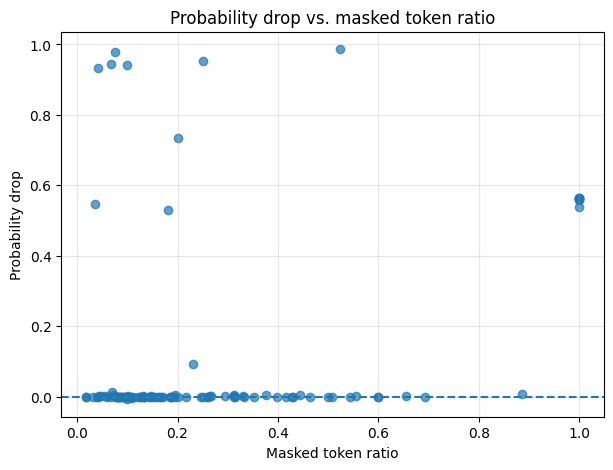

In [15]:
plt.figure(figsize=(7, 5))

plt.scatter(
    eval_df["masked_token_ratio"],
    eval_df["prob_drop"],
    alpha=0.7
)

plt.axhline(0, linestyle="--")
plt.xlabel("Masked token ratio")
plt.ylabel("Probability drop")
plt.title("Probability drop vs. masked token ratio")
plt.grid(True, alpha=0.3)
plt.show()